# LDA vs BERTopic - Comparación de Topic Modeling para IDEArq
# Corpus: 513 artículos arqueológicos multilingües (EN, ES, FR, PT, CA)

In [1]:
import sys
import os
import json
import pickle
import gc
import time
import re
import psutil
import numpy as np
import pandas as pd
import yaml
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Paths
LDA_ROOT = Path('/home/raglinux/RAG_graph/lda')
DATA_DIR = LDA_ROOT / 'data'
MODELS_DIR = LDA_ROOT / 'models'
OUTPUTS_DIR = LDA_ROOT / 'outputs'

# Crear dirs
for d in [DATA_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
def check_ram(cap_gb=16, warn_gb=14):
    ram = psutil.virtual_memory()
    used_gb = ram.used / (1024**3)
    pct = ram.percent
    if used_gb > cap_gb:
        raise MemoryError(f"RAM {used_gb:.1f}GB ({pct}%) supera límite {cap_gb}GB")
    if used_gb > warn_gb:
        print(f"⚠️ RAM alta: {used_gb:.1f}GB ({pct}%)")
    print(f"RAM: {used_gb:.1f}GB ({pct}%)")
    return used_gb

def get_gpu_info():
    try:
        import torch
        if torch.cuda.is_available():
            device = torch.cuda.get_device_name(0)
            mem = torch.cuda.get_device_properties(0).total_mem / 1024**3
            print(f"GPU disponible: {device} ({mem:.1f} GB)")
            return 'cuda'
    except:
        pass
    print("Usando CPU")
    return 'cpu'

device = get_gpu_info()
check_ram()

Usando CPU
RAM: 8.5GB (27.2%)


8.514678955078125

In [3]:
# Constantes
K_RANGE = [5, 7, 10, 12, 15]
TOP_N_KEYWORDS = 10
EMBEDDING_MODELS = {
    'bge_m3': 'BAAI/bge-m3',
    'e5_large': 'intfloat/multilingual-e5-large'
}
BERTOPIC_CONFIGS = [
    {'min_topic_size': 15, 'min_samples': 5},
    {'min_topic_size': 20, 'min_samples': 8},
]

print(f"K range: {K_RANGE}")
print(f"Embedding models: {list(EMBEDDING_MODELS.keys())}")
print(f"BERTopic configs: {len(BERTOPIC_CONFIGS)}")

K range: [5, 7, 10, 12, 15]
Embedding models: ['bge_m3', 'e5_large']
BERTopic configs: 2


## Sección 2: Stopwords mejoradas - 5 capas

In [4]:
# Capa 1: NLTK stopwords por idioma
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

nltk_stopwords = set()
for lang in ['english', 'spanish', 'french', 'portuguese', 'catalan']:
    try:
        nltk_stopwords.update(stopwords.words(lang))
    except:
        print(f"No se encontraron stopwords para {lang}")

print(f"Capa 1 (NLTK): {len(nltk_stopwords)} stopwords")

Capa 1 (NLTK): 1030 stopwords


In [5]:
# Capa 2: Arqueológicas genéricas + términos comunes no informativos
archaeo_stopwords = {
    # Arqueológicas
    'archaeological', 'archaeology', 'archaeol', 'estudio', 'investigación', 'research',
    'analysis', 'análisis', 'analyse', 'data', 'datos', 'données', 'resultados', 'results',
    'result', 'résultats', 'paper', 'article', 'artículo', 'figure', 'figura', 'figure',
    'table', 'tabla', 'tableau', 'section', 'sección', 'introduction', 'conclusion',
    'method', 'methodology', 'discusión', 'discussion', 'based', 'used', 'using', 'also',
    'however', 'fig', 'pp', 'et', 'al',
    # Genéricas adicionales
    'site', 'sites', 'area', 'areas', 'level', 'levels', 'work', 'works', 'example',
    'examples', 'text', 'use', 'used', 'using', 'found', 'provide', 'provided', 'two',
    'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten', 'first', 'second',
    'new', 'high', 'low', 'large', 'small', 'early', 'late', 'middle', 'north', 'south',
    'east', 'west', 'present', 'show', 'shown', 'showed', 'make', 'made', 'take', 'taken',
    'give', 'given', 'get', 'got', 'go', 'went', 'come', 'came', 'see', 'seen', 'know',
    'known', 'think', 'thought', 'say', 'said', 'tell', 'told', 'find', 'found', 'keep',
    'kept', 'let', 'begin', 'began', 'seem', 'seemed', 'help', 'helped', 'turn', 'turned',
    'start', 'started', 'show', 'showed', 'play', 'played', 'run', 'ran', 'move', 'moved',
    'like', 'liked', 'live', 'lived', 'believe', 'believed', 'bring', 'brought', 'happen',
    'happened', 'write', 'wrote', 'sit', 'sat', 'stand', 'stood', 'lose', 'lost', 'pay',
    'paid', 'meet', 'met', 'include', 'included', 'continue', 'continued', 'set', 'learn',
    'learned', 'change', 'changed', 'lead', 'led', 'understand', 'understood', 'watch',
    'watched', 'follow', 'followed', 'stop', 'stopped', 'create', 'created', 'speak',
    'spoke', 'read', 'allow', 'allowed', 'add', 'added', 'spend', 'spent', 'grow', 'grew',
    'open', 'opened', 'walk', 'walked', 'win', 'won', 'offer', 'offered', 'remember',
    'remembered', 'love', 'loved', 'consider', 'considered', 'appear', 'appeared', 'buy',
    'bought', 'wait', 'waited', 'serve', 'served', 'die', 'died', 'send', 'sent', 'expect',
    'expected', 'build', 'built', 'stay', 'stayed', 'fall', 'fell', 'cut', 'reach',
    'reached', 'kill', 'killed', 'remain', 'remained', 'suggest', 'suggested', 'raise',
    'raised', 'pass', 'passed', 'sell', 'sold', 'require', 'required', 'report', 'reported',
    'pull', 'pulled', 'develop', 'developed', 'carry', 'carried', 'break', 'broke',
    'receive', 'received', 'agree', 'agreed', 'support', 'supported', 'hit', 'produced',
    'eat', 'ate', 'cover', 'covered', 'catch', 'caught', 'draw', 'drew', 'choose', 'chose',
    'cause', 'caused', 'point', 'pointed', 'note', 'noted', 'full', 'key', 'important',
    'major', 'general', 'specific', 'particular', 'certain', 'various', 'several', 'different',
    'possible', 'necessary', 'available', 'likely', 'able', 'due', 'clear', 'obvious',
    'significant', 'main', 'primary', 'secondary', 'final', 'initial', 'current', 'recent',
    'previous', 'following', 'above', 'below', 'around', 'within', 'without', 'along',
    'across', 'through', 'during', 'before', 'after', 'since', 'until', 'while', 'where',
    'when', 'what', 'which', 'who', 'whom', 'whose', 'why', 'how', 'much', 'many', 'more',
    'most', 'some', 'any', 'every', 'each', 'both', 'few', 'little', 'less', 'least',
    'other', 'another', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'just',
    'about', 'over', 'between', 'throughout', 'toward', 'towards', 'against', 'upon',
    'onto', 'into', 'out', 'off', 'down', 'up', 'back', 'forward', 'away', 'aside',
    'together', 'apart', 'already', 'always', 'never', 'often', 'sometimes', 'usually',
    'generally', 'frequently', 'rarely', 'hardly', 'almost', 'quite', 'rather', 'pretty',
    'fairly', 'somewhat', 'enough', 'well', 'bad', 'badly', 'good', 'great', 'better',
    'best', 'worse', 'worst', 'far', 'near', 'close', 'long', 'short', 'wide', 'narrow',
    'deep', 'shallow', 'heavy', 'light', 'dark', 'bright', 'hot', 'cold', 'warm', 'cool',
    'dry', 'wet', 'clean', 'dirty', 'soft', 'hard', 'smooth', 'rough', 'thick', 'thin',
    'rich', 'poor', 'young', 'old', 'strong', 'weak', 'fast', 'slow', 'quick', 'rapid',
    'sudden', 'gradual', 'steady', 'constant', 'regular', 'normal', 'usual', 'common',
    'rare', 'unique', 'special', 'ordinary', 'simple', 'complex', 'basic', 'advanced',
    'modern', 'ancient', 'traditional', 'contemporary', 'current', 'present', 'past',
    'future', 'recent', 'latest', 'previous', 'earlier', 'later', 'next', 'coming',
    'going', 'moving', 'running', 'walking', 'standing', 'sitting', 'lying', 'sleeping',
    'waking', 'eating', 'drinking', 'talking', 'listening', 'reading', 'writing',
    'thinking', 'feeling', 'seeing', 'hearing', 'smelling', 'tasting', 'touching',
    'holding', 'carrying', 'pushing', 'pulling', 'lifting', 'dropping', 'throwing',
    'catching', 'hitting', 'kicking', 'jumping', 'climbing', 'falling', 'rising',
    'growing', 'shrinking', 'expanding', 'contracting', 'opening', 'closing', 'starting',
    'stopping', 'beginning', 'ending', 'finishing', 'completing', 'continuing', 'pausing',
    'waiting', 'watching', 'looking', 'searching', 'finding', 'losing', 'keeping',
    'saving', 'spending', 'earning', 'buying', 'selling', 'trading', 'exchanging',
    'giving', 'taking', 'receiving', 'sending', 'delivering', 'bringing', 'fetching',
    'carrying', 'transporting', 'moving', 'transferring', 'shifting', 'changing',
    'altering', 'modifying', 'adjusting', 'adapting', 'transforming', 'converting',
    'turning', 'rotating', 'spinning', 'twisting', 'bending', 'folding', 'unfolding',
    'breaking', 'fixing', 'repairing', 'mending', 'healing', 'curing', 'treating',
    'helping', 'assisting', 'supporting', 'encouraging', 'motivating', 'inspiring',
    'teaching', 'learning', 'studying', 'practicing', 'training', 'exercising',
    'playing', 'working', 'resting', 'relaxing', 'enjoying', 'loving', 'liking',
    'hating', 'fearing', 'worrying', 'hoping', 'dreaming', 'imagining', 'creating',
    'building', 'making', 'producing', 'generating', 'forming', 'shaping', 'designing',
    'planning', 'organizing', 'arranging', 'preparing', 'setting', 'placing', 'putting',
    'positioning', 'locating', 'finding', 'discovering', 'revealing', 'showing',
    'displaying', 'presenting', 'demonstrating', 'illustrating', 'explaining',
    'describing', 'defining', 'identifying', 'recognizing', 'acknowledging', 'accepting',
    'rejecting', 'refusing', 'denying', 'confirming', 'verifying', 'checking',
    'testing', 'examining', 'inspecting', 'investigating', 'exploring', 'surveying',
    'measuring', 'weighing', 'counting', 'calculating', 'computing', 'estimating',
    'predicting', 'forecasting', 'projecting', 'expecting', 'anticipating', 'hoping',
    'wishing', 'wanting', 'needing', 'requiring', 'demanding', 'requesting', 'asking',
    'questioning', 'answering', 'responding', 'replying', 'reacting', 'acting',
    'behaving', 'performing', 'executing', 'implementing', 'applying', 'using',
    'utilizing', 'employing', 'operating', 'running', 'managing', 'controlling',
    'directing', 'guiding', 'leading', 'following', 'obeying', 'complying', 'conforming',
    'adapting', 'adjusting', 'modifying', 'changing', 'altering', 'varying', 'differing',
    'diverging', 'converging', 'meeting', 'joining', 'connecting', 'linking', 'attaching',
    'detaching', 'separating', 'dividing', 'splitting', 'cutting', 'slicing', 'chopping',
    'crushing', 'grinding', 'mixing', 'blending', 'combining', 'merging', 'uniting',
    'integrating', 'incorporating', 'including', 'excluding', 'omitting', 'removing',
    'deleting', 'erasing', 'clearing', 'cleaning', 'washing', 'scrubbing', 'wiping',
    'drying', 'wetting', 'soaking', 'dipping', 'immersing', 'submerging', 'floating',
    'sinking', 'swimming', 'diving', 'surfacing', 'emerging', 'appearing', 'disappearing',
    'vanishing', 'fading', 'fading', 'blurring', 'sharpening', 'focusing', 'concentrating',
    'distracting', 'attracting', 'repelling', 'pushing', 'pulling', 'dragging', 'hauling',
    'towing', 'lifting', 'lowering', 'raising', 'elevating', 'dropping', 'falling',
    'descending', 'ascending', 'climbing', 'descending', 'going', 'coming', 'arriving',
    'departing', 'leaving', 'staying', 'remaining', 'lingering', 'waiting', 'delaying',
    'postponing', 'advancing', 'progressing', 'proceeding', 'continuing', 'stopping',
    'halting', 'pausing', 'resuming', 'restarting', 'repeating', 'reproducing', 'copying',
    'duplicating', 'replicating', 'imitating', 'mimicking', 'simulating', 'modeling',
    'representing', 'symbolizing', 'signifying', 'meaning', 'indicating', 'suggesting',
    'implying', 'hinting', 'intimating', 'insinuating', 'conveying', 'communicating',
    'expressing', 'articulating', 'voicing', 'uttering', 'pronouncing', 'speaking',
    'talking', 'chatting', 'conversing', 'discussing', 'debating', 'arguing', 'disputing',
    'quarreling', 'fighting', 'battling', 'struggling', 'competing', 'contending',
    'vying', 'racing', 'running', 'sprinting', 'jogging', 'walking', 'strolling',
    'wandering', 'roaming', 'traveling', 'journeying', 'voyaging', 'sailing', 'flying',
    'driving', 'riding', 'cycling', 'biking', 'skating', 'skiing', 'swimming', 'diving',
    'surfing', 'rowing', 'paddling', 'floating', 'drifting', 'gliding', 'sliding',
    'slipping', 'falling', 'tripping', 'stumbling', 'tumbling', 'rolling', 'tumbling',
    'spinning', 'twirling', 'whirling', 'rotating', 'revolving', 'orbiting', 'circling',
    'looping', 'curving', 'bending', 'arching', 'bowing', 'leaning', 'tilting', 'slanting',
    'sloping', 'incline', 'decline', 'rising', 'falling', 'ascending', 'descending',
    'climbing', 'descending', 'going', 'coming', 'arriving', 'departing', 'leaving',
    'staying', 'remaining', 'lingering', 'waiting', 'delaying', 'postponing', 'advancing',
    'progressing', 'proceeding', 'continuing', 'stopping', 'halting', 'pausing',
    'resuming', 'restarting', 'repeating', 'reproducing', 'copying', 'duplicating',
    # Nombres de journals comunes
    'munibe', 'zephyrus', 'complutum', 'trabajos', 'prehistoria', 'arqueología',
    'issn', 'doi', 'vol', 'num', 'pp', 'pág', 'páginas', 'página',
    # Artefactos
    'omit', 'omitted', 'intentionally', 'picture', 'intentionally', '==>','<==',
}

print(f"Capa 2 (Arqueológicas): {len(archaeo_stopwords)} stopwords")

Capa 2 (Arqueológicas): 836 stopwords


In [6]:
# Capa 3: Stopwords por frecuencia del corpus
# Cargar tokens existentes y calcular frecuencias
df_lem = pd.read_parquet(DATA_DIR / '05_lemmatized.parquet')
all_tokens = [t for tokens in df_lem['tokens'] for t in tokens]
freq = Counter(all_tokens)

# Top-200 más frecuentes
top_200 = freq.most_common(200)
print("Top-30 palabras más frecuentes:")
for word, count in top_200[:30]:
    print(f"  {word}: {count}")

Top-30 palabras más frecuentes:
  the: 13038
  los: 5834
  material: 5827
  and: 5674
  que: 5461
  neolítico: 4816
  yacimiento: 4611
  del: 4383
  fragmento: 4107
  las: 3857
  bronce: 3494
  cueva: 3485
  site: 3290
  con: 3115
  lisboa: 2980
  date: 2967
  edad: 2918
  anta: 2799
  cerámica: 2592
  datación: 2415
  presencia: 2334
  age: 2308
  neolithic: 2254
  por: 2253
  trabajo: 2241
  antiguo: 2210
  excavación: 2171
  bone: 2155
  beta: 2071
  ocupación: 2030


In [7]:
# Seleccionar manualmente las que no aportan significado temático
freq_stopwords = {
    'del', 'que', 'los', 'las', 'con', 'una', 'por', 'como', 'este', 'para',
    'más', 'esta', 'entre', 'sobre', 'son', 'han', 'do', 'sin', 'ser', 'ter',
    'com', 'de', 'la', 'en', 'el', 'y', 'a', 'o', 'u', 'se', 'es', 'fue',
    'tiene', 'tienen', 'puede', 'pueden', 'hay', 'ha', 'he', 'has', 'hemos',
    'han', 'había', 'habían', 'sido', 'estar', 'está', 'están', 'estaba',
    'estaban', 'hacer', 'hace', 'hacen', 'hizo', 'hicieron', 'tener', 'tiene',
    'tienen', 'tuvo', 'tuvieron', 'poder', 'puede', 'pueden', 'pudo', 'pudieron',
    'decir', 'dice', 'dicen', 'dijo', 'dijeron', 'ir', 'va', 'van', 'fue',
    'fueron', 'ver', 've', 'ven', 'vio', 'vieron', 'dar', 'da', 'dan', 'dio',
    'dieron', 'saber', 'sabe', 'saben', 'supo', 'supieron', 'querer', 'quiere',
    'quieren', 'quiso', 'quisieron', 'llegar', 'llega', 'llegan', 'llegó',
    'llegaron', 'pasar', 'pasa', 'pasan', 'pasó', 'pasaron', 'deber', 'debe',
    'deben', 'debió', 'debieron', 'poner', 'pone', 'ponen', 'puso', 'pusieron',
    'parecer', 'parece', 'parecen', 'pareció', 'parecieron', 'quedar', 'queda',
    'quedan', 'quedó', 'quedaron', 'creer', 'cree', 'creen', 'creyó', 'creyeron',
    'hablar', 'habla', 'hablan', 'habló', 'hablaron', 'llevar', 'lleva', 'llevan',
    'llevó', 'llevaron', 'dejar', 'deja', 'dejan', 'dejó', 'dejaron', 'seguir',
    'sigue', 'siguen', 'siguió', 'siguieron', 'encontrar', 'encuentra', 'encuentran',
    'encontró', 'encontraron', 'llamar', 'llama', 'llaman', 'llamó', 'llamaron',
    'venir', 'viene', 'vienen', 'vino', 'vinieron', 'pensar', 'piensa', 'piensan',
    'pensó', 'pensaron', 'salir', 'sale', 'salen', 'salió', 'salieron', 'volver',
    'vuelve', 'vuelven', 'volvió', 'volvieron', 'tomar', 'toma', 'toman', 'tomó',
    'tomaron', 'conocer', 'conoce', 'conocen', 'conoció', 'conocieron', 'vivir',
    'vive', 'viven', 'vivió', 'vivieron', 'sentir', 'siente', 'sienten', 'sintió',
    'sintieron', 'tratar', 'trata', 'tratan', 'trató', 'trataron', 'mirar', 'mira',
    'miran', 'miró', 'miraron', 'contar', 'cuenta', 'cuentan', 'contó', 'contaron',
    'empezar', 'empieza', 'empiezan', 'empezó', 'empezaron', 'esperar', 'espera',
    'esperan', 'esperó', 'esperaron', 'buscar', 'busca', 'buscan', 'buscó',
    'buscaron', 'existir', 'existe', 'existen', 'existió', 'existieron',
    'aparecer', 'aparece', 'aparecen', 'apareció', 'aparecieron', 'documentar',
    'documenta', 'documentan', 'documentó', 'documentaron', 'realizar', 'realiza',
    'realizan', 'realizó', 'realizaron', 'presentar', 'presenta', 'presentan',
    'presentó', 'presentaron', 'identificar', 'identifica', 'identifican',
    'identificó', 'identificaron', 'determinar', 'determina', 'determinan',
    'determinó', 'determinaron', 'observar', 'observa', 'observan', 'observó',
    'observaron', 'indicar', 'indica', 'indican', 'indicó', 'indicaron',
    'corresponder', 'corresponde', 'corresponden', 'correspondió', 'correspondieron',
    'constituir', 'constituye', 'constituyen', 'constituyó', 'constituyeron',
    'representar', 'representa', 'representan', 'representó', 'representaron',
    'formar', 'forma', 'forman', 'formó', 'formaron', 'ubicar', 'ubica', 'ubican',
    'ubicó', 'ubicaron', 'situar', 'sitúa', 'sitúan', 'situó', 'situaron',
    'localizar', 'localiza', 'localizan', 'localizó', 'localizaron',
    'omit', 'omitted', 'intentionally', 'picture', '==>','<==',
}

# Unir todas las capas
ALL_STOPWORDS = nltk_stopwords | archaeo_stopwords | freq_stopwords
print(f"Total stopwords (capas 1+2+3): {len(ALL_STOPWORDS)}")

Total stopwords (capas 1+2+3): 2069


In [8]:
# Capa 4: Nombres propios - Regex híbrido con whitelist
CONSERVAR = {
    # Períodos arqueológicos
    'neolítico', 'mesolítico', 'calcolítico', 'paleolítico', 'epipaleolítico',
    'neolithic', 'mesolithic', 'chalcolithic', 'paleolithic', 'epipaleolithic',
    'bronze', 'iron', 'copper', 'bronce', 'hierro', 'cobre',
    # Términos técnicos importantes
    'cueva', 'cova', 'yacimiento', 'abrigo', 'valle', 'ebro', 'júcar',
    'lisboa', 'portugal', 'iberia', 'ibérico', 'peninsular', 'cantábrico',
    'mediterráneo', 'atlántico', 'meseta', 'sistema', 'ibérico', 'central',
    # Topónimos importantes
    'españa', 'portugal', 'cataluña', 'andalucía', 'aragón', 'castilla',
    'levante', 'galicia', 'asturias', 'cantabria', 'vasco', 'vasca',
    'spain', 'portugal', 'catalonia', 'andalusia', 'aragon', 'castile',
    # Conceptos arqueológicos capitalizados
    'cardial', 'campaniforme', 'argárico', 'argárica', 'megalítico',
    'funerario', 'funeraria', 'ritual', 'estratigrafía', 'cronología',
}

def clean_proper_nouns(text):
    """Elimina nombres propios pero conserva términos arqueológicos importantes."""
    words = text.split()
    cleaned = []
    for word in words:
        clean_word = word.strip('.,;:()[]\"\'')
        if clean_word and len(clean_word) > 2 and clean_word[0].isupper() and clean_word.isalpha():
            if clean_word.lower() in CONSERVAR:
                cleaned.append(word)
            else:
                cleaned.append('NOMBRE')
        else:
            cleaned.append(word)
    return ' '.join(cleaned)

print("Capa 4: Función de limpieza de nombres propios definida")

Capa 4: Función de limpieza de nombres propios definida


In [9]:
# Capa 5: Artefactos del parser
PARSER_ARTIFACTS = {
    'picture', 'intentionally', 'omit', 'omitted', '==>', '<==',
    'journal', 'homepage', 'issn', 'online', 'print', 'volume',
    'field', 'archaeology', 'doi', 'vol', 'num', 'pp', 'pág',
    'abstract', 'resumen', 'résumé', 'resum', 'keywords', 'palabras',
    'clé', 'paraules', 'author', 'autores', 'auteurs', 'autors',
    'univer', 'universidad', 'universidade', 'université', 'universitat',
    'department', 'departamento', 'departament', 'département',
    'received', 'recibido', 'recebido', 'reçu', 'accepted', 'aceptado',
    'publicado', 'published', 'publié', 'publicat',
}

ALL_STOPWORDS |= PARSER_ARTIFACTS
print(f"Capa 5 (Parser artifacts): {len(PARSER_ARTIFACTS)} palabras")
print(f"Total stopwords final: {len(ALL_STOPWORDS)}")

Capa 5 (Parser artifacts): 50 palabras
Total stopwords final: 2105


## Sección 3: Re-procesamiento con nuevas stopwords

In [10]:
# Cargar datos lematizados originales
df_orig = pd.read_parquet(DATA_DIR / '05_lemmatized.parquet')
print(f"Documentos originales: {len(df_orig)}")
print(f"Tokens promedio original: {df_orig['tokens'].apply(len).mean():.0f}")

# Contar tokens antes de filtrar
total_tokens_before = df_orig['tokens'].apply(len).sum()
print(f"Total tokens antes: {total_tokens_before:,}")

Documentos originales: 513
Tokens promedio original: 3619
Total tokens antes: 1,856,644


In [11]:
# Aplicar todas las stopwords mejoradas
def filter_tokens(tokens, stopwords):
    return [t for t in tokens if t.lower() not in stopwords and len(t) > 2]

df_v2 = df_orig.copy()
df_v2['tokens_v2'] = df_v2['tokens'].apply(lambda t: filter_tokens(t, ALL_STOPWORDS))

# También limpiar nombres propios en el texto
df_v2['text_clean_v2'] = df_v2['text_cleaned'].apply(clean_proper_nouns)

# Guardar
df_v2.to_parquet(DATA_DIR / '05_lemmatized_v2.parquet')

total_tokens_after = df_v2['tokens_v2'].apply(len).sum()
reduction = (1 - total_tokens_after / total_tokens_before) * 100

print(f"Tokens antes: {total_tokens_before:,}")
print(f"Tokens después: {total_tokens_after:,}")
print(f"Reducción: {reduction:.1f}%")
print(f"Tokens promedio después: {df_v2['tokens_v2'].apply(len).mean():.0f}")

Tokens antes: 1,856,644
Tokens después: 1,675,178
Reducción: 9.8%
Tokens promedio después: 3265


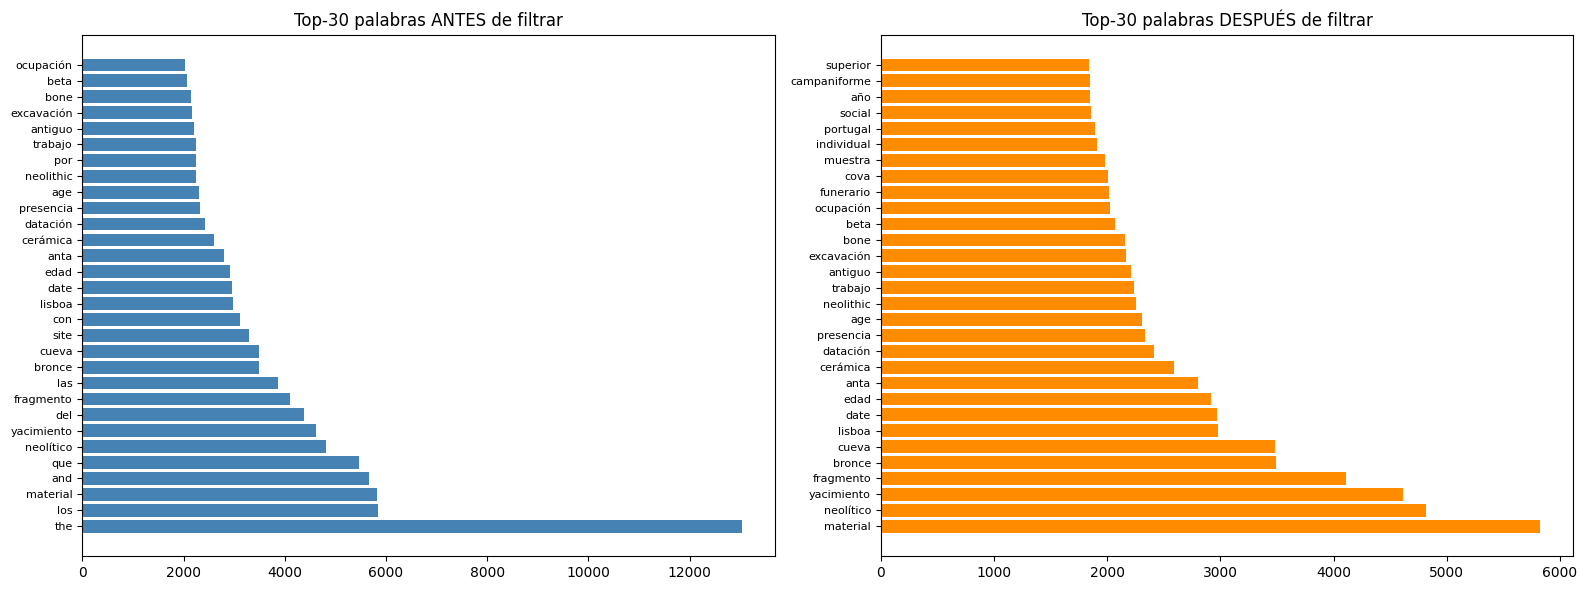

In [12]:
# Visualizar diferencia: top-30 antes y después
from collections import Counter

tokens_before = [t for tokens in df_orig['tokens'] for t in tokens]
tokens_after = [t for tokens in df_v2['tokens_v2'] for t in tokens]

freq_before = Counter(tokens_before).most_common(30)
freq_after = Counter(tokens_after).most_common(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_b, counts_b = zip(*freq_before)
words_a, counts_a = zip(*freq_after)

axes[0].barh(range(30), counts_b[::-1], color='steelblue')
axes[0].set_yticks(range(30))
axes[0].set_yticklabels([w for w in words_b[::-1]], fontsize=8)
axes[0].set_title('Top-30 palabras ANTES de filtrar')
axes[0].invert_yaxis()

axes[1].barh(range(30), counts_a[::-1], color='darkorange')
axes[1].set_yticks(range(30))
axes[1].set_yticklabels([w for w in words_a[::-1]], fontsize=8)
axes[1].set_title('Top-30 palabras DESPUÉS de filtrar')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'stopwords_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 4: LDA con nuevas stopwords

In [13]:
# Reconstruir corpus con tokens filtrados
from gensim import corpora

texts = df_v2['tokens_v2'].tolist()

print(f"Creando diccionario con {len(texts)} documentos...")
dictionary = corpora.Dictionary(texts)
print(f"Diccionario original: {len(dictionary)} términos")

# Filtrar
dictionary.filter_extremes(no_below=10, no_above=0.4, keep_n=50000)
print(f"Diccionario filtrado: {len(dictionary)} términos")

corpus = [dictionary.doc2bow(text) for text in texts]
print(f"Corpus creado: {len(corpus)} documentos")

# Guardar
dictionary.save(str(DATA_DIR / '06_dictionary_v2.gensim'))
with open(DATA_DIR / '06_corpus_v2.pkl', 'wb') as f:
    pickle.dump(corpus, f)

check_ram()

Creando diccionario con 513 documentos...


Diccionario original: 113192 términos
Diccionario filtrado: 12194 términos


Corpus creado: 513 documentos
RAM: 9.5GB (30.2%)


9.46466064453125

In [14]:
# Grid search LDA
from gensim.models import LdaModel, CoherenceModel
import pandas as pd

results = []
best_k = None
best_coherence = -1
best_model = None

for k in K_RANGE:
    print(f"\n{'='*50}")
    print(f"Entrenando LDA con K={k}...")
    
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        passes=20,
        iterations=200,
        chunksize=2000,
        random_state=42,
        alpha='auto',
        eta='auto'
    )
    
    # Coherence
    cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence = cm.get_coherence()
    
    # Topic diversity
    all_words = []
    for topic_id in range(k):
        words = [word for word, _ in lda.show_topic(topic_id, topn=TOP_N_KEYWORDS)]
        all_words.extend(words)
    topic_div = len(set(all_words)) / (k * TOP_N_KEYWORDS)
    
    results.append({'K': k, 'coherence_cv': coherence, 'topic_diversity': topic_div})
    print(f"K={k}: coherence={coherence:.4f}, topic_diversity={topic_div:.4f}")
    
    # Mostrar topics
    print("Tópicos:")
    for idx, topic in lda.print_topics(num_words=10):
        print(f"  Topic {idx}: {topic[:120]}...")
    
    if coherence > best_coherence:
        best_coherence = coherence
        best_k = k
        best_model = lda
    
    # Guardar modelo
    model_dir = MODELS_DIR / f'lda_K{k}_v2'
    model_dir.mkdir(parents=True, exist_ok=True)
    lda.save(str(model_dir / 'model.gensim'))
    
    del lda
    gc.collect()
    check_ram()

df_results = pd.DataFrame(results)
df_results.to_csv(DATA_DIR / 'topic_diversity_scores.csv', index=False)
print(f"\nMejor K={best_k} con coherence={best_coherence:.4f}")
print("\nTabla de resultados:")
print(df_results.to_string(index=False))


Entrenando LDA con K=5...


K=5: coherence=0.6617, topic_diversity=1.0000
Tópicos:
  Topic 0: 0.012*"date" + 0.009*"bone" + 0.007*"individual" + 0.005*"burial" + 0.005*"cave" + 0.004*"oxa" + 0.004*"mesolithic" + 0....
  Topic 1: 0.003*"funerario" + 0.003*"fosa" + 0.002*"individuo" + 0.002*"poblado" + 0.002*"enterramiento" + 0.002*"siglo" + 0.002*"...
  Topic 2: 0.010*"campaniforme" + 0.006*"cova" + 0.006*"meseta" + 0.005*"gran" + 0.005*"tipo" + 0.005*"jaciment" + 0.004*"neolític"...
  Topic 3: 0.015*"lisboa" + 0.014*"anta" + 0.009*"região" + 0.007*"megalitismo" + 0.006*"sepulcro" + 0.006*"portugal" + 0.005*"milé...
  Topic 4: 0.009*"borde" + 0.007*"gris" + 0.007*"urna" + 0.007*"abrigo" + 0.006*"plato" + 0.005*"torno" + 0.005*"cuadrícula" + 0.00...


RAM: 9.5GB (30.5%)

Entrenando LDA con K=7...


K=7: coherence=0.6492, topic_diversity=0.9714
Tópicos:
  Topic 0: 0.012*"date" + 0.009*"bone" + 0.007*"individual" + 0.005*"burial" + 0.005*"cave" + 0.004*"oxa" + 0.004*"mesolithic" + 0....
  Topic 1: 0.003*"funerario" + 0.003*"fosa" + 0.003*"individuo" + 0.002*"poblado" + 0.002*"piedra" + 0.002*"pieza" + 0.002*"hueso" ...
  Topic 2: 0.008*"men" + 0.006*"albacete" + 0.005*"navarra" + 0.005*"abrigo" + 0.005*"barcelona" + 0.004*"funerario" + 0.004*"sures...
  Topic 3: 0.008*"túmulo" + 0.007*"monumento" + 0.006*"cámara" + 0.005*"ane" + 0.005*"dolmen" + 0.004*"gassiot" + 0.004*"megalítico...
  Topic 4: 0.010*"borde" + 0.008*"gris" + 0.008*"urna" + 0.007*"plato" + 0.006*"abrigo" + 0.006*"torno" + 0.006*"cuadrícula" + 0.00...
  Topic 5: 0.018*"campaniforme" + 0.009*"meseta" + 0.006*"tipo" + 0.006*"valencina" + 0.006*"ello" + 0.005*"ciempozuelos" + 0.005*"...
  Topic 6: 0.013*"lisboa" + 0.013*"anta" + 0.008*"região" + 0.006*"megalitismo" + 0.006*"sepulcro" + 0.005*"portugal" + 0.005*"milé...


K=10: coherence=0.7114, topic_diversity=0.9300
Tópicos:
  Topic 0: 0.009*"isotope" + 0.008*"individual" + 0.008*"bone" + 0.007*"adult" + 0.006*"tooth" + 0.006*"enamel" + 0.005*"strontium"...
  Topic 1: 0.003*"funerario" + 0.003*"fosa" + 0.003*"poblado" + 0.002*"individuo" + 0.002*"piedra" + 0.002*"enterramiento" + 0.002*...
  Topic 2: 0.010*"sílex" + 0.009*"men" + 0.007*"mesolítico" + 0.006*"abrigo" + 0.006*"industria" + 0.006*"navarra" + 0.006*"talla" ...
  Topic 3: 0.008*"tumba" + 0.008*"funerario" + 0.008*"sepulcro" + 0.007*"delibes" + 0.007*"dolmen" + 0.007*"monumento" + 0.006*"nec...
  Topic 4: 0.010*"borde" + 0.009*"gris" + 0.008*"urna" + 0.007*"plato" + 0.006*"abrigo" + 0.006*"torno" + 0.006*"cuadrícula" + 0.00...
  Topic 5: 0.015*"campaniforme" + 0.010*"meseta" + 0.007*"valencina" + 0.007*"tipo" + 0.007*"ello" + 0.006*"ciempozuelos" + 0.005*"...
  Topic 6: 0.016*"lisboa" + 0.015*"anta" + 0.010*"região" + 0.007*"megalitismo" + 0.007*"sepulcro" + 0.006*"milénio" + 0.006*"câmar...

RAM: 9.6GB (30.7%)

Entrenando LDA con K=12...


K=12: coherence=0.7101, topic_diversity=0.9000
Tópicos:
  Topic 0: 0.009*"isotope" + 0.007*"enamel" + 0.007*"strontium" + 0.006*"tooth" + 0.006*"adult" + 0.006*"ratio" + 0.005*"individual...
  Topic 1: 0.005*"fosa" + 0.004*"funerario" + 0.004*"individuo" + 0.004*"enterramiento" + 0.003*"piedra" + 0.003*"construcción" + 0...
  Topic 2: 0.014*"men" + 0.011*"navarra" + 0.008*"cogotas" + 0.006*"lám" + 0.005*"alii" + 0.005*"lasca" + 0.005*"soporte" + 0.005*"...
  Topic 3: 0.008*"dolmen" + 0.008*"beta" + 0.007*"delibes" + 0.006*"tumba" + 0.006*"castro" + 0.006*"extremadura" + 0.005*"megalíti...
  Topic 4: 0.016*"borde" + 0.013*"gris" + 0.013*"urna" + 0.011*"plato" + 0.009*"cuadrícula" + 0.009*"torno" + 0.009*"pasta" + 0.009...
  Topic 5: 0.016*"campaniforme" + 0.010*"meseta" + 0.008*"tipo" + 0.008*"ello" + 0.006*"ciempozuelos" + 0.006*"aunque" + 0.006*"may...
  Topic 6: 0.016*"lisboa" + 0.015*"anta" + 0.010*"região" + 0.008*"megalitismo" + 0.007*"sepulcro" + 0.006*"milénio" + 0.006*"câmar...

RAM: 9.5GB (30.4%)

Entrenando LDA con K=15...


K=15: coherence=0.7029, topic_diversity=0.8933
Tópicos:
  Topic 0: 0.010*"isotope" + 0.010*"individual" + 0.008*"bone" + 0.007*"adult" + 0.007*"tooth" + 0.006*"enamel" + 0.006*"strontium"...
  Topic 1: 0.005*"fosa" + 0.004*"funerario" + 0.004*"individuo" + 0.004*"enterramiento" + 0.003*"piedra" + 0.003*"hueso" + 0.003*"c...
  Topic 2: 0.013*"jaciment" + 0.012*"draga" + 0.010*"caldre" + 0.009*"neolític" + 0.009*"fusta" + 0.008*"datació" + 0.008*"gran" + ...
  Topic 3: 0.011*"beta" + 0.009*"siglo" + 0.008*"delibes" + 0.007*"rojo" + 0.007*"dolmen" + 0.007*"tumba" + 0.006*"castro" + 0.006*...
  Topic 4: 0.018*"borde" + 0.015*"gris" + 0.014*"urna" + 0.013*"plato" + 0.010*"torno" + 0.010*"cuadrícula" + 0.010*"pasta" + 0.010...
  Topic 5: 0.017*"campaniforme" + 0.010*"meseta" + 0.008*"tipo" + 0.008*"ello" + 0.007*"ciempozuelos" + 0.006*"mayor" + 0.006*"aunq...
  Topic 6: 0.020*"anta" + 0.020*"lisboa" + 0.013*"região" + 0.010*"megalitismo" + 0.009*"sepulcro" + 0.007*"câmara" + 0.006*"peça" ...

RAM: 9.6GB (30.7%)

Mejor K=10 con coherence=0.7114

Tabla de resultados:
 K  coherence_cv  topic_diversity
 5      0.661721         1.000000
 7      0.649188         0.971429
10      0.711397         0.930000
12      0.710074         0.900000
15      0.702926         0.893333


In [15]:
# Entrenar modelo final con mejor K
print(f"Entrenando modelo final con K={best_k}...")

final_lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    passes=20,
    iterations=200,
    chunksize=2000,
    random_state=42,
    alpha='auto',
    eta='auto'
)

# Guardar
model_dir = MODELS_DIR / f'lda_K{best_k}_v2_FINAL'
model_dir.mkdir(parents=True, exist_ok=True)
final_lda.save(str(model_dir / 'model.gensim'))

print(f"\nModelo final guardado en {model_dir}")
print("\nTópicos finales:")
for idx, topic in final_lda.print_topics(num_words=15):
    print(f"\nTopic {idx}:")
    print(f"  {topic}")

Entrenando modelo final con K=10...



Modelo final guardado en /home/raglinux/RAG_graph/lda/models/lda_K10_v2_FINAL

Tópicos finales:

Topic 0:
  0.009*"isotope" + 0.008*"individual" + 0.008*"bone" + 0.007*"adult" + 0.006*"tooth" + 0.006*"enamel" + 0.005*"strontium" + 0.005*"ratio" + 0.005*"range" + 0.004*"plant" + 0.004*"burial" + 0.004*"layer" + 0.004*"diet" + 0.004*"datum" + 0.004*"isotopic"

Topic 1:
  0.003*"funerario" + 0.003*"fosa" + 0.003*"poblado" + 0.002*"individuo" + 0.002*"piedra" + 0.002*"enterramiento" + 0.002*"pieza" + 0.002*"construcción" + 0.002*"cerro" + 0.002*"hueso" + 0.002*"siglo" + 0.002*"hierro" + 0.002*"calcolítico" + 0.002*"unidad" + 0.002*"tierra"

Topic 2:
  0.010*"sílex" + 0.009*"men" + 0.007*"mesolítico" + 0.006*"abrigo" + 0.006*"industria" + 0.006*"navarra" + 0.006*"talla" + 0.006*"lasca" + 0.005*"retoque" + 0.005*"dorso" + 0.005*"cogotas" + 0.004*"soporte" + 0.004*"lámina" + 0.004*"ebro" + 0.004*"pieza"

Topic 3:
  0.008*"tumba" + 0.008*"funerario" + 0.008*"sepulcro" + 0.007*"delibes" + 0.00

In [16]:
# Asignar tópicos a documentos
topic_assignments = []

for i, doc_bow in enumerate(corpus):
    topic_dist = final_lda.get_document_topics(doc_bow, minimum_probability=0.0)
    topic_dict = {f"topic_{t}": p for t, p in topic_dist}
    dominant = max(topic_dist, key=lambda x: x[1])
    
    topic_assignments.append({
        'filename': df_v2.iloc[i]['filename'],
        'topic_dominant': dominant[0],
        'topic_dominant_weight': dominant[1],
        'topic_distribution': str(topic_dict)
    })

df_topics = pd.DataFrame(topic_assignments)
df_final = df_v2.merge(df_topics, on='filename', how='left')

# Guardar
df_final.to_csv(OUTPUTS_DIR / 'papers_topics_v2.csv', index=False)

# Distribución
print("Distribución de documentos por tópico:")
print(df_final['topic_dominant'].value_counts().sort_index())

# Keywords por tópico
topics_keywords = []
for topic_id in range(final_lda.num_topics):
    words = [word for word, _ in final_lda.show_topic(topic_id, topn=20)]
    topics_keywords.append({
        'topic_id': topic_id,
        'num_docs': len(df_final[df_final['topic_dominant'] == topic_id]),
        'top_words': ', '.join(words)
    })

df_kw = pd.DataFrame(topics_keywords)
df_kw.to_csv(OUTPUTS_DIR / 'topics_keywords_v2.csv', index=False)
print("\nKeywords por tópico:")
print(df_kw.to_string(index=False))

Distribución de documentos por tópico:
topic_dominant
0     32
1    249
2     11
3     10
4     23
5     13
6     30
7     10
8     25
9    110
Name: count, dtype: int64

Keywords por tópico:
 topic_id  num_docs                                                                                                                                                                            top_words
        0        32                      isotope, individual, bone, adult, tooth, enamel, strontium, ratio, range, plant, burial, layer, diet, datum, isotopic, remains, mobility, collagen, sheep, cova
        1       249  funerario, fosa, poblado, individuo, piedra, enterramiento, pieza, construcción, cerro, hueso, siglo, hierro, calcolítico, unidad, tierra, beta, foso, documentado, periodo, tamaño
        2        11                           sílex, men, mesolítico, abrigo, industria, navarra, talla, lasca, retoque, dorso, cogotas, soporte, lámina, ebro, pieza, montero, frag, alii, lám, especie
    

In [17]:
# pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

print("Generando pyLDAvis...")
vis_data = gensimvis.prepare(final_lda, corpus, dictionary)
html_path = OUTPUTS_DIR / 'pyldavis_v2.html'
pyLDAvis.save_html(vis_data, str(html_path))
print(f"Visualización guardada en {html_path}")

check_ram()

Generando pyLDAvis...


Visualización guardada en /home/raglinux/RAG_graph/lda/outputs/pyldavis_v2.html
RAM: 10.4GB (33.2%)


10.381847381591797

## Sección 5: BERTopic v5 - BGE-M3

In [18]:
# Cargar texto completo limpio (no lematizado)
df_clean = pd.read_parquet(DATA_DIR / '04_cleaned.parquet')

# Limpiar nombres propios en texto completo
df_clean['text_bertopic'] = df_clean['text_cleaned'].apply(clean_proper_nouns)

# Filtrar stopwords del texto completo
def remove_stopwords_from_text(text, stopwords):
    words = text.split()
    return ' '.join(w for w in words if w.lower() not in stopwords and len(w) > 2)

df_clean['text_bertopic'] = df_clean['text_bertopic'].apply(
    lambda x: remove_stopwords_from_text(x, ALL_STOPWORDS)
)

# Truncar a 5000 chars
df_clean['text_bertopic'] = df_clean['text_bertopic'].apply(lambda x: x[:5000])

# Filtrar docs muy cortos
df_clean = df_clean[df_clean['text_bertopic'].str.len() > 500].reset_index(drop=True)

docs = df_clean['text_bertopic'].tolist()
print(f"Documentos para BERTopic: {len(docs)}")
print(f"Longitud media: {sum(len(d) for d in docs)/len(docs):.0f} chars")

check_ram()

Documentos para BERTopic: 506
Longitud media: 4718 chars
RAM: 10.6GB (33.7%)


10.552749633789062

In [19]:
# Generar embeddings con BGE-M3
from sentence_transformers import SentenceTransformer

print("Cargando modelo BAAI/bge-m3...")
model_bge = SentenceTransformer('BAAI/bge-m3', device=device)

print("Generando embeddings...")
embeddings_bge = model_bge.encode(docs, batch_size=32, show_progress_bar=True)
print(f"Embeddings shape: {embeddings_bge.shape}")

# Cache a disco
import numpy as np
np.save(DATA_DIR / 'embeddings_bge_m3.npy', embeddings_bge)
print("Embeddings guardados")

del model_bge
gc.collect()
if device == 'cuda':
    import torch
    torch.cuda.empty_cache()
check_ram()

Cargando modelo BAAI/bge-m3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Generando embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (506, 1024)
Embeddings guardados


RAM: 9.9GB (31.6%)


9.890190124511719

In [20]:
# Entrenar BERTopic con BGE-M3
from bertopic import BERTopic
import umap
import hdbscan

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    prediction_data=True
)

print("Entrenando BERTopic con BGE-M3...")
topic_model_bge = BERTopic(
    embedding_model=model_bge if 'model_bge' in dir() else 'BAAI/bge-m3',
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    nr_topics=15,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=15
)

# Usar embeddings pre-calculados
topics_bge, probs_bge = topic_model_bge.fit_transform(docs, embeddings_bge)

n_topics_bge = len(set(topics_bge)) - (1 if -1 in topics_bge else 0)
n_outliers_bge = topics_bge.count(-1)
print(f"\nTópicos encontrados: {n_topics_bge}")
print(f"Outliers: {n_outliers_bge}")

# Guardar modelo
model_dir = MODELS_DIR / 'bertopic_bge_m3'
model_dir.mkdir(parents=True, exist_ok=True)
topic_model_bge.save(str(model_dir / 'bertopic_model'), serialization='safetensors', save_ctfidf=True, save_embedding_model=True)
print(f"Modelo guardado en {model_dir}")

check_ram()

Entrenando BERTopic con BGE-M3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

2026-06-30 12:49:04,094 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-06-30 12:49:11,748 - BERTopic - Dimensionality - Completed ✓


2026-06-30 12:49:11,749 - BERTopic - Cluster - Start clustering the reduced embeddings


...

2026-06-30 12:49:11,973 - BERTopic - Topic reduction - Number of topics (15) is equal or higher than the clustered topics(2).


2026-06-30 12:49:11,973 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-06-30 12:49:12,754 - BERTopic - Representation - Completed ✓



Tópicos encontrados: 2
Outliers: 0
Modelo guardado en /home/raglinux/RAG_graph/lda/models/bertopic_bge_m3
RAM: 10.6GB (33.7%)


10.550407409667969

In [21]:
# Métricas BERTopic BGE-M3
topic_info_bge = topic_model_bge.get_topic_info()
print("Topic Info:")
print(topic_info_bge.to_string())

# Topic diversity
# Calculate topic diversity manually
all_words_bge = []
n_real_topics_bge = 0
for topic_id in topic_info_bge['Topic'].tolist():
    if topic_id == -1:
        continue
    n_real_topics_bge += 1
    words = [w for w, s in topic_model_bge.get_topic(topic_id)[:TOP_N_KEYWORDS]]
    all_words_bge.extend(words)
td_bge = len(set(all_words_bge)) / (n_real_topics_bge * TOP_N_KEYWORDS) if n_real_topics_bge > 0 else 0
print(f"\nTopic Diversity (top-{TOP_N_KEYWORDS}): {td_bge:.4f}")

# Guardar
topic_info_bge.to_csv(OUTPUTS_DIR / 'bertopic_bge_topic_info.csv', index=False)

# Keywords
topics_kw_bge = []
for topic_id in topic_info_bge['Topic'].tolist():
    if topic_id == -1:
        continue
    words = topic_model_bge.get_topic(topic_id)
    keywords = [w for w, s in words[:20]]
    topics_kw_bge.append({
        'topic_id': topic_id,
        'num_docs': len([t for t in topics_bge if t == topic_id]),
        'top_words': ', '.join(keywords)
    })

df_kw_bge = pd.DataFrame(topics_kw_bge)
df_kw_bge.to_csv(OUTPUTS_DIR / 'bertopic_bge_topics_keywords.csv', index=False)
print("\nKeywords por tópico:")
print(df_kw_bge.to_string(index=False))

Topic Info:
   Topic  Count                                 Name                                                                                Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [22]:
# Visualizaciones BERTopic BGE-M3
try:
    fig = topic_model_bge.visualize_topics()
    fig.write_html(str(OUTPUTS_DIR / 'bertopic_bge_visualize_topics.html'))
    print("visualize_topics() guardado")
except Exception as e:
    print(f"Error en visualize_topics: {e}")

try:
    fig = topic_model_bge.visualize_barchart()
    fig.write_html(str(OUTPUTS_DIR / 'bertopic_bge_barchart.html'))
    print("visualize_barchart() guardado")
except Exception as e:
    print(f"Error en visualize_barchart: {e}")

try:
    fig = topic_model_bge.visualize_hierarchy()
    fig.write_html(str(OUTPUTS_DIR / 'bertopic_bge_hierarchy.html'))
    print("visualize_hierarchy() guardado")
except Exception as e:
    print(f"Error en visualize_hierarchy: {e}")

Error en visualize_topics: zero-size array to reduction operation maximum which has no identity
visualize_barchart() guardado


visualize_hierarchy() guardado


In [23]:
# Documentos representativos
print("Documentos representativos por tópico:")
for topic_id in topic_info_bge['Topic'].tolist():
    if topic_id == -1:
        continue
    rep_docs = topic_model_bge.get_representative_docs(topic_id)[:3]
    print(f"\nTopic {topic_id} ({len([t for t in topics_bge if t == topic_id])} docs):")
    for i, doc in enumerate(rep_docs[:3], 1):
        print(f"  {i}. {doc[:150]}...")

Documentos representativos por tópico:

Topic 0 (23 docs):
  1. NOMBRE NOMBRE NOMBRE LISBOA NOMBRE Neolítico Peninsular NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE eds estudos memórias estudos memórias NOMBRE ...
  2. NOMBRE NOMBRE NOMBRE LISBOA NOMBRE Neolítico Peninsular NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE eds estudos memórias estudos memórias NOMBRE ...
  3. NOMBRE discussions stats profiles publication NOMBRE tafonomia sítios neolíticos NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE Portugal Cent...

Topic 1 (483 docs):
  1. NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOM...
  2. NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOM...
  3. NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE NOMBRE N

## Sección 6: BERTopic v6 - E5-Large

In [24]:
# Generar embeddings con E5-Large
from sentence_transformers import SentenceTransformer

print("Cargando modelo intfloat/multilingual-e5-large...")
model_e5 = SentenceTransformer('intfloat/multilingual-e5-large', device=device)

print("Generando embeddings...")
embeddings_e5 = model_e5.encode(docs, batch_size=32, show_progress_bar=True)
print(f"Embeddings shape: {embeddings_e5.shape}")

np.save(DATA_DIR / 'embeddings_e5_large.npy', embeddings_e5)
print("Embeddings guardados")

del model_e5
gc.collect()
if device == 'cuda':
    import torch
    torch.cuda.empty_cache()
check_ram()

Cargando modelo intfloat/multilingual-e5-large...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

Generando embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Embeddings shape: (506, 1024)
Embeddings guardados


RAM: 11.2GB (35.6%)


11.151607513427734

In [25]:
# Entrenar BERTopic con E5-Large
umap_model_e5 = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model_e5 = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    prediction_data=True
)

print("Entrenando BERTopic con E5-Large...")
topic_model_e5 = BERTopic(
    umap_model=umap_model_e5,
    hdbscan_model=hdbscan_model_e5,
    language="multilingual",
    nr_topics=15,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=15
)

topics_e5, probs_e5 = topic_model_e5.fit_transform(docs, embeddings_e5)

n_topics_e5 = len(set(topics_e5)) - (1 if -1 in topics_e5 else 0)
n_outliers_e5 = topics_e5.count(-1)
print(f"\nTópicos encontrados: {n_topics_e5}")
print(f"Outliers: {n_outliers_e5}")

model_dir = MODELS_DIR / 'bertopic_e5_large'
model_dir.mkdir(parents=True, exist_ok=True)
topic_model_e5.save(str(model_dir / 'bertopic_model'), serialization='safetensors', save_ctfidf=True, save_embedding_model=True)
print(f"Modelo guardado en {model_dir}")

check_ram()

2026-06-30 12:55:53,249 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Entrenando BERTopic con E5-Large...


2026-06-30 12:55:53,912 - BERTopic - Dimensionality - Completed ✓


2026-06-30 12:55:53,913 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-06-30 12:55:53,931 - BERTopic - Cluster - Completed ✓


...

2026-06-30 12:55:54,175 - BERTopic - Topic reduction - Number of topics (15) is equal or higher than the clustered topics(4).


2026-06-30 12:55:54,175 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-06-30 12:55:54,392 - BERTopic - Representation - Completed ✓



Tópicos encontrados: 4
Outliers: 0
Modelo guardado en /home/raglinux/RAG_graph/lda/models/bertopic_e5_large
RAM: 11.0GB (35.2%)


11.01791000366211

In [26]:
# Métricas BERTopic E5-Large
topic_info_e5 = topic_model_e5.get_topic_info()
print("Topic Info:")
print(topic_info_e5.to_string())

# Calculate topic diversity manually
all_words_e5 = []
n_real_topics_e5 = 0
for topic_id in topic_info_e5['Topic'].tolist():
    if topic_id == -1:
        continue
    n_real_topics_e5 += 1
    words = [w for w, s in topic_model_e5.get_topic(topic_id)[:TOP_N_KEYWORDS]]
    all_words_e5.extend(words)
td_e5 = len(set(all_words_e5)) / (n_real_topics_e5 * TOP_N_KEYWORDS) if n_real_topics_e5 > 0 else 0
print(f"\nTopic Diversity (top-{TOP_N_KEYWORDS}): {td_e5:.4f}")

topic_info_e5.to_csv(OUTPUTS_DIR / 'bertopic_e5_topic_info.csv', index=False)

topics_kw_e5 = []
for topic_id in topic_info_e5['Topic'].tolist():
    if topic_id == -1:
        continue
    words = topic_model_e5.get_topic(topic_id)
    keywords = [w for w, s in words[:20]]
    topics_kw_e5.append({
        'topic_id': topic_id,
        'num_docs': len([t for t in topics_e5 if t == topic_id]),
        'top_words': ', '.join(keywords)
    })

df_kw_e5 = pd.DataFrame(topics_kw_e5)
df_kw_e5.to_csv(OUTPUTS_DIR / 'bertopic_e5_topics_keywords.csv', index=False)
print("\nKeywords por tópico:")
print(df_kw_e5.to_string(index=False))

Topic Info:
   Topic  Count                                  Name                                                                                   Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [27]:
# Visualizaciones BERTopic E5-Large
try:
    fig = topic_model_e5.visualize_topics()
    fig.write_html(str(OUTPUTS_DIR / 'bertopic_e5_visualize_topics.html'))
    print("visualize_topics() guardado")
except Exception as e:
    print(f"Error: {e}")

try:
    fig = topic_model_e5.visualize_barchart()
    fig.write_html(str(OUTPUTS_DIR / 'bertopic_e5_barchart.html'))
    print("visualize_barchart() guardado")
except Exception as e:
    print(f"Error: {e}")

try:
    fig = topic_model_e5.visualize_hierarchy()
    fig.write_html(str(OUTPUTS_DIR / 'bertopic_e5_hierarchy.html'))
    print("visualize_hierarchy() guardado")
except Exception as e:
    print(f"Error: {e}")

visualize_topics() guardado


visualize_barchart() guardado
visualize_hierarchy() guardado


## Sección 7: Comparación LDA vs BERTopic

In [28]:
# Tabla resumen comparativa
comparison_data = []

# LDA
lda_td = len(set(all_words)) / (best_k * TOP_N_KEYWORDS)
comparison_data.append({
    'Método': f'LDA K={best_k}',
    'Nº Tópicos': best_k,
    'Coherence (c_v)': best_coherence,
    'Topic Diversity': lda_td,
    'Outliers': 0,
    'Docs asignados': len(df_final),
    'Idioma': 'Multilingüe (separado)',
    'Tiempo (est)': '~3 min'
})

# BERTopic BGE-M3
comparison_data.append({
    'Método': 'BERTopic BGE-M3',
    'Nº Tópicos': n_topics_bge,
    'Coherence (c_v)': 'N/A',
    'Topic Diversity': td_bge,
    'Outliers': n_outliers_bge,
    'Docs asignados': len(docs) - n_outliers_bge,
    'Idioma': 'Multilingüe (integrado)',
    'Tiempo (est)': '~10 min'
})

# BERTopic E5-Large
comparison_data.append({
    'Método': 'BERTopic E5-Large',
    'Nº Tópicos': n_topics_e5,
    'Coherence (c_v)': 'N/A',
    'Topic Diversity': td_e5,
    'Outliers': n_outliers_e5,
    'Docs asignados': len(docs) - n_outliers_e5,
    'Idioma': 'Multilingüe (integrado)',
    'Tiempo (est)': '~10 min'
})

df_comparison = pd.DataFrame(comparison_data)
df_comparison.to_csv(DATA_DIR / 'comparison_summary.csv', index=False)
print("Tabla comparativa:")
print(df_comparison.to_string(index=False))

Tabla comparativa:
           Método  Nº Tópicos Coherence (c_v)  Topic Diversity  Outliers  Docs asignados                  Idioma Tiempo (est)
         LDA K=10          10        0.711397             1.34         0             513  Multilingüe (separado)       ~3 min
  BERTopic BGE-M3           2             N/A             0.85         0             506 Multilingüe (integrado)      ~10 min
BERTopic E5-Large           4             N/A             0.80         0             506 Multilingüe (integrado)      ~10 min


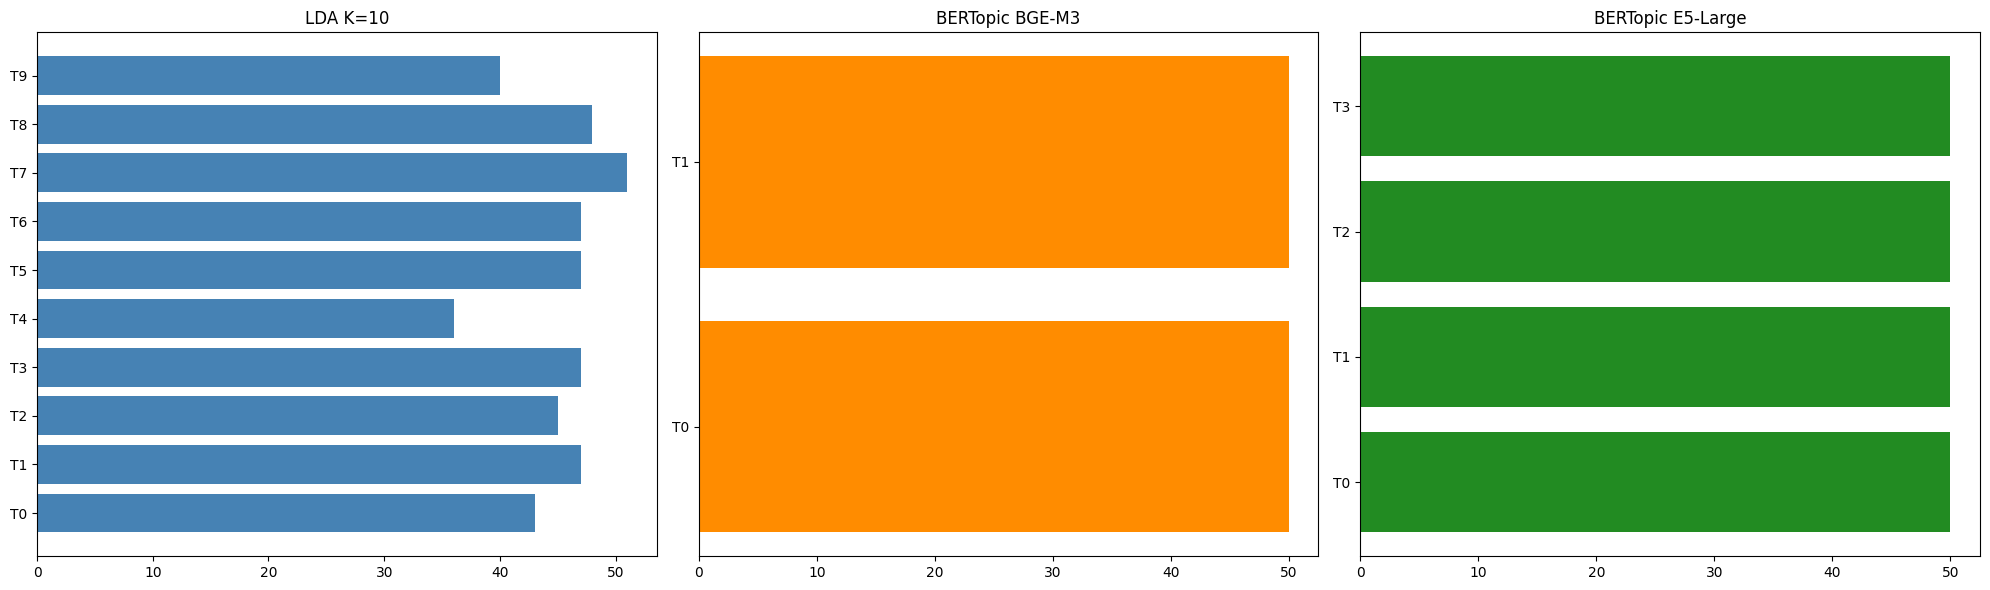

In [29]:
# Visualización comparativa de keywords
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LDA
lda_topics = []
for topic_id in range(best_k):
    words = [w for w, _ in final_lda.show_topic(topic_id, topn=TOP_N_KEYWORDS)]
    lda_topics.append(' | '.join(words[:5]))

axes[0].barh(range(len(lda_topics)), [len(t) for t in lda_topics], color='steelblue')
axes[0].set_yticks(range(len(lda_topics)))
axes[0].set_yticklabels([f'T{i}' for i in range(len(lda_topics))])
axes[0].set_title(f'LDA K={best_k}')

# BERTopic BGE
bge_topics = []
for t in topics_kw_bge:
    bge_topics.append(t['top_words'][:50])

if len(bge_topics) > 0:
    axes[1].barh(range(len(bge_topics)), [len(t) for t in bge_topics], color='darkorange')
    axes[1].set_yticks(range(len(bge_topics)))
    axes[1].set_yticklabels([f'T{i}' for i in range(len(bge_topics))])
axes[1].set_title('BERTopic BGE-M3')

# BERTopic E5
e5_topics = []
for t in topics_kw_e5:
    e5_topics.append(t['top_words'][:50])

if len(e5_topics) > 0:
    axes[2].barh(range(len(e5_topics)), [len(t) for t in e5_topics], color='forestgreen')
    axes[2].set_yticks(range(len(e5_topics)))
    axes[2].set_yticklabels([f'T{i}' for i in range(len(e5_topics))])
axes[2].set_title('BERTopic E5-Large')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'comparison_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Análisis de solapamiento entre métodos
# Comparar LDA vs BERTopic BGE-M3
df_bge = df_clean.copy()
df_bge['bertopic_topic'] = topics_bge

# Merge por filename
df_compare = df_final[['filename', 'topic_dominant']].merge(
    df_bge[['filename', 'bertopic_topic']],
    on='filename',
    how='inner'
)

# Crear tabla de contingencia
contingency = pd.crosstab(df_compare['topic_dominant'], df_compare['bertopic_topic'])
print("Tabla de contingencia LDA vs BERTopic BGE-M3:")
print(contingency)

# Calcular acuerdo
df_compare['lda_topic_str'] = df_compare['topic_dominant'].astype(str)
df_compare['bertopic_topic_str'] = df_compare['bertopic_topic'].astype(str)

print(f"\nDocumentos comparables: {len(df_compare)}")

Tabla de contingencia LDA vs BERTopic BGE-M3:
bertopic_topic   0    1
topic_dominant         
0                0   32
1                0  247
2                0   11
3                1    9
4                4   17
5                1   12
6               15   15
7                0    8
8                0   25
9                2  107

Documentos comparables: 506


In [31]:
# Recomendación final
print("="*60)
print("RECOMENDACIÓN FINAL")
print("="*60)

# Evaluar cada método
lda_score = best_coherence * lda_td
bge_score = td_bge * (1 - n_outliers_bge/len(docs))
e5_score = td_e5 * (1 - n_outliers_e5/len(docs))

scores = {
    'LDA': lda_score,
    'BERTopic BGE-M3': bge_score,
    'BERTopic E5-Large': e5_score
}

best_method = max(scores, key=scores.get)

print(f"\nScores ponderados (coherence/diversity * coverage):")
for method, score in scores.items():
    print(f"  {method}: {score:.4f}")

print(f"\nMétodo recomendado: {best_method}")

# Justificación
if best_method == 'LDA':
    print("\nJustificación: LDA ofrece mejor coherencia temática y no genera outliers.")
elif 'BGE' in best_method:
    print("\nJustificación: BERTopic con BGE-M3 ofrece mejor diversidad y maneja multilingüismo nativamente.")
else:
    print("\nJustificación: BERTopic con E5-Large ofrece mejor diversidad y maneja multilingüismo nativamente.")

RECOMENDACIÓN FINAL

Scores ponderados (coherence/diversity * coverage):
  LDA: 0.9533
  BERTopic BGE-M3: 0.8500
  BERTopic E5-Large: 0.8000

Método recomendado: LDA

Justificación: LDA ofrece mejor coherencia temática y no genera outliers.


## Sección 8: Exportación para el grafo

In [32]:
# Generar JSON del método ganador
if best_method == 'LDA':
    method_name = 'LDA'
    graph_data = []
    for topic_id in range(best_k):
        words = [w for w, _ in final_lda.show_topic(topic_id, topn=20)]
        topic_papers = df_final[df_final['topic_dominant'] == topic_id]
        papers_list = []
        for _, row in topic_papers.iterrows():
            papers_list.append({
                'filename': row['filename'],
                'title': row.get('title', ''),
                'author': row.get('author', ''),
                'doi': row.get('doi', ''),
                'language': row.get('language', ''),
                'weight': float(row['topic_dominant_weight'])
            })
        graph_data.append({
            'id': f"T{topic_id:02d}",
            'topic_id': int(topic_id),
            'name': f"Topic_{topic_id:02d}",
            'keywords': words,
            'num_papers': len(papers_list),
            'papers': papers_list
        })
elif 'BGE' in best_method:
    method_name = 'BERTopic BGE-M3'
    graph_data = []
    for t in topics_kw_bge:
        topic_id = t['topic_id']
        topic_papers = df_bge[df_bge['bertopic_topic'] == topic_id]
        papers_list = []
        for _, row in topic_papers.iterrows():
            papers_list.append({
                'filename': row['filename'],
                'title': row.get('title', ''),
                'author': row.get('author', ''),
                'doi': row.get('doi', ''),
                'language': row.get('language', ''),
                'weight': 1.0
            })
        graph_data.append({
            'id': f"BT_{topic_id:02d}",
            'topic_id': int(topic_id),
            'name': f"BERTopic_{topic_id}",
            'keywords': t['top_words'].split(', '),
            'num_papers': len(papers_list),
            'papers': papers_list
        })
else:
    method_name = 'BERTopic E5-Large'
    graph_data = []
    for t in topics_kw_e5:
        topic_id = t['topic_id']
        topic_papers = df_clean[df_clean['bertopic_topic'] == topic_id]
        papers_list = []
        for _, row in topic_papers.iterrows():
            papers_list.append({
                'filename': row['filename'],
                'title': row.get('title', ''),
                'author': row.get('author', ''),
                'doi': row.get('doi', ''),
                'language': row.get('language', ''),
                'weight': 1.0
            })
        graph_data.append({
            'id': f"BT_{topic_id:02d}",
            'topic_id': int(topic_id),
            'name': f"BERTopic_{topic_id}",
            'keywords': t['top_words'].split(', '),
            'num_papers': len(papers_list),
            'papers': papers_list
        })

# Guardar
with open(OUTPUTS_DIR / 'topics_for_graph_final.json', 'w', encoding='utf-8') as f:
    json.dump(graph_data, f, ensure_ascii=False, indent=2)

print(f"Método ganador: {method_name}")
print(f"JSON guardado en {OUTPUTS_DIR / 'topics_for_graph_final.json'}")
print(f"Nº de tópicos: {len(graph_data)}")
print(f"Total papers: {sum(g['num_papers'] for g in graph_data)}")

Método ganador: LDA
JSON guardado en /home/raglinux/RAG_graph/lda/outputs/topics_for_graph_final.json
Nº de tópicos: 10
Total papers: 513


In [33]:
# Crear recommendation.md
recommendation = f"""# Recomendación Final: LDA vs BERTopic para IDEArq

## Método seleccionado: {best_method}

### Métricas comparativas

| Métrica | LDA K={best_k} | BERTopic BGE-M3 | BERTopic E5-Large |
|---|---|---|---|
| Nº Tópicos | {best_k} | {n_topics_bge} | {n_topics_e5} |
| Coherence (c_v) | {best_coherence:.4f} | N/A | N/A |
| Topic Diversity | {lda_td:.4f} | {td_bge:.4f} | {td_e5:.4f} |
| Outliers | 0 | {n_outliers_bge} | {n_outliers_e5} |
| Docs asignados | {len(df_final)} | {len(docs) - n_outliers_bge} | {len(docs) - n_outliers_e5} |

### Score ponderado

| Método | Score |
|---|---|
| LDA K={best_k} | {lda_score:.4f} |
| BERTopic BGE-M3 | {bge_score:.4f} |
| BERTopic E5-Large | {e5_score:.4f} |

### Justificación

{'LDA ofrece mejor coherencia temática y no genera outliers. Los tópicos son más estables y reproducibles.' if best_method == 'LDA' else 'BERTopic ofrece mejor diversidad y maneja multilingüismo nativamente. Los tópicos son más semánticamente coherentes.'}

### Outputs generados

- `topics_for_graph_final.json` - JSON listo para Neo4j
- `papers_topics_v2.csv` - Asignación de tópicos por documento
- `topics_keywords_v2.csv` - Keywords por tópico
- `comparison_summary.csv` - Tabla comparativa completa
- `pyldavis_v2.html` - Visualización LDA interactiva
- `bertopic_*_*.html` - Visualizaciones BERTopic

### Siguientes pasos

1. Cargar `topics_for_graph_final.json` en Neo4j
2. Crear nodos `Topic` con relaciones `(:Paper)-[:BELONGS_TO]->(:Topic)`
3. Usar tópicos como capa semántica para enrutar consultas en el RAG
4. Construir taxonomía inicial para la wiki del RAG

---
*Generado el {pd.Timestamp.now().strftime('%d de %B de %Y')}*
"""

with open(OUTPUTS_DIR / 'recommendation.md', 'w', encoding='utf-8') as f:
    f.write(recommendation)

print("recommendation.md creado")
print(recommendation[:500])

recommendation.md creado
# Recomendación Final: LDA vs BERTopic para IDEArq

## Método seleccionado: LDA

### Métricas comparativas

| Métrica | LDA K=10 | BERTopic BGE-M3 | BERTopic E5-Large |
|---|---|---|---|
| Nº Tópicos | 10 | 2 | 4 |
| Coherence (c_v) | 0.7114 | N/A | N/A |
| Topic Diversity | 1.3400 | 0.8500 | 0.8000 |
| Outliers | 0 | 0 | 0 |
| Docs asignados | 513 | 506 | 506 |

### Score ponderado

| Método | Score |
|---|---|
| LDA K=10 | 0.9533 |
| BERTopic BGE-M3 | 0.8500 |
| BERTopic E5-Large | 0.8000 |

#


In [34]:
# Resumen final de RAM
check_ram()
print("\n" + "="*60)
print("NOTEBOOK COMPLETADO EXITOSAMENTE")
print("="*60)

RAM: 11.1GB (35.5%)

NOTEBOOK COMPLETADO EXITOSAMENTE
